### Hydrological Analysis

The WhiteboxTools library provides a comprehensive set of tools for hydrological analysis of raster data. In this notebook, it is used to analyse terrain derived from the previously processed Digital Terrain Model (DTM)

The analysis includes:

- Depression filling
- Flow direction and accumulation
- Stream network extraction
- Visual comparison of OS Open Rivers to the WhiteBoxTools generated river network.
- DTM correction 
- Calculate Strahler stream order

List of data used:
- OS Open Rivers: https://www.ordnancesurvey.co.uk/products/os-open-rivers
- UK Lakes: https://www.data.gov.uk/dataset/899e3816-b760-4eb4-a1f1-34fc7858f705/spatial-inventory-of-uk-waterbodies 

### First, let's import whitebox and get our environment ready

In [36]:
import os
import whitebox

# For visualisation
import rasterio
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
from rasterio.plot import show
from osgeo import gdal
import numpy as np

In [17]:
wbt = whitebox.WhiteboxTools()  # Create WhiteboxTools object
wbt.set_verbose_mode(False)  # Disable detailed logging

data_dir = ('/home/users/ambbar/GIthub/data/processed/39088')
wbt.set_working_dir(data_dir)

os.chdir("/home/users/ambbar/GIthub/data/processed/39088")

In [18]:
# Define input files 
extracted_dem = 'dtm_39088_extract.tif'

### Now, let's extract the stream network and generate the watershed in our study area by:
1. Filling the depressions in the DTM
2. Getting the flow directions
3. Processing flow accumulations
4. Defining a threshold above which accumulated flow we have our rivers

In [19]:
# Fill any depressions caused by gaps in a DTM 

def generate_watershed_files(input_dem: str, filled_dem: str,
                             flow_dir_path: str,
                             flow_accum_path: str,
                             stream_path: str, streamlines_output: str,
                             stream_threshold: int = 50000) -> str:
    """
    Generate watershed analysis outputs using WhiteboxTools.

    Parameters
    ----------
    input_dem : str
        Path to the DEM raster (DTM).
    filled_dem : str
        Output path for filled DTM raster 
    flow_dir_path : str
        Output path for flow direction raster.
    flow_accum_path : str
        Output path for flow accumulation raster.
    stream_path : str
        Output path for extracted stream raster.
    streamlines_output : str
        Output path for streamlines vector.
    stream_threshold : int, optional
        Threshold for stream extraction (default=50000).

    Returns
    ----------
    str
        Path to the streamlines shapefile.
    """

    # Fill any depressions/sinks in the DEM
    wbt.fill_depressions(dem=input_dem, output=filled_dem)
    print('Filling depressions in the DEM')

    # Generate the flow direction file, results show which direction run-off
    # travels in.
    wbt.d8_pointer(dem=filled_dem, output=flow_dir_path)
    print('Generating flow direction')

    # From the flow direction file, flow accumulation is calculated. The higher
    # the value for a cell, the greater
    # the volume of run-off there is at that particular cell.
    wbt.d8_flow_accumulation(i=flow_dir_path, output=flow_accum_path,
                             out_type='specific contributing area', pntr=True)
    print('Calculating flow accumulation in cells')
    
    # Streams can be extracted by selecting cells with high flow accumulation,
    # which is defined here by the threshold
    wbt.extract_streams(
        flow_accum=flow_accum_path,
        output=stream_path,
        threshold=stream_threshold)
    print('Extracting streams')
    
    # Convert this to a vector format.
    wbt.raster_streams_to_vector(
        streams=stream_path,
        d8_pntr=flow_dir_path,
        output=streamlines_output,
        esri_pntr=False
    )
    print('Creating shapefile')
    
    return streamlines_output, stream_path

In [20]:
streamlines = generate_watershed_files(
    extracted_dem, filled_dem=f"filled_{extracted_dem}",
    flow_dir_path=f"flow_dir_{extracted_dem}",
    flow_accum_path=f"flow_accum_{extracted_dem}",
    stream_path=f"stream_{extracted_dem}",
    streamlines_output="streamlines.shp")


Filling depressions in the DEM
Generating flow direction
Calculating flow accumulation in cells
Extracting streams
Creating shapefile


In [21]:
# save the raster stream path to file to use later on for analysis
output_stream_path = f"stream_{extracted_dem}"
input_d8_pointer = f"flow_dir_{extracted_dem}"

### 🌊 Visualising and Comparing River Networks

To evaluate the quality of the derived river network, we will compare it against an external reference dataset.

Steps:

- Download and load the reference river dataset for comparison
- Load the generated river network
- Overlay both datasets to visually assess differences

Differences between the two datasets are expected and can be informative:

Using a low flow accumulation threshold when generating rivers will typically result in:
- More dense river networks
- Inclusion of smaller upstream tributaries
- This often leads to discrepancies when compared to generalised or coarser-resolution reference datasets

As a result, areas of mismatch may highlight:

- Over-detection (too many tributaries)
- Under-detection (missing channels)
- Differences in resolution or data processing methods

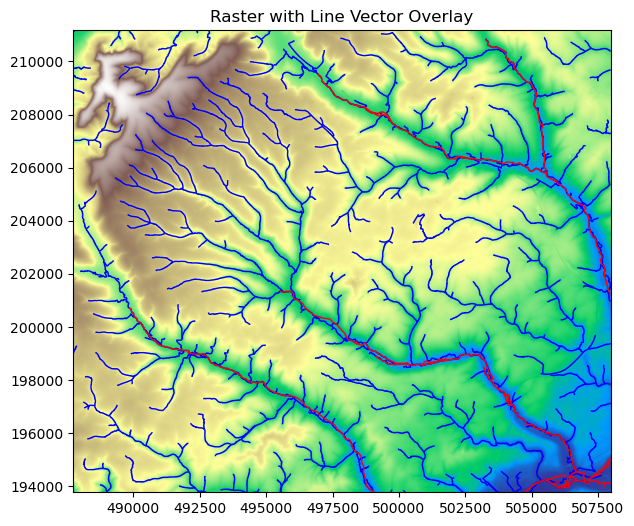

In [24]:
# Open raster
with rasterio.open(extracted_dem) as src:
    raster = src.read(1)  # Read the first band
    minx, maxx, miny, maxy = src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top
    extent = [minx, maxx, miny, maxy]

# Open stream networks
gen_rivers = gpd.read_file("streamlines.shp")
os_rivers = gpd.read_file("WatercourseLink.shp")
os_rivers = os_rivers.clip((minx, miny, maxx, maxy))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
show(raster, extent=extent, ax=ax, cmap="terrain")  # Adjust cmap as needed
gen_rivers.plot(ax=ax, edgecolor="blue", linewidth=1)  # Overlay line vector
os_rivers.plot(ax=ax, edgecolor="red", linewidth=1)

plt.title("Raster with Line Vector Overlay")
plt.show()

### We can now do some post-processing to cleanup and compare the hydrological features. We will correct our DTM by using the OS Open Rivers, so that flow directions will be forced to follow the river flow paths. 

In [25]:
def burned_paths(input_dem: str, burned_dem: str,
                             burned_filled_path: str,
                             burned_flow_dir_path: str,
                             burned_flow_accum_path: str,
                             burned_stream_path: str,
                             burned_pruned_stream_path: str,
                             burned_streamlines_output: str,
                             stream_min_length: int = 250, 
                             burned_stream_threshold: int = 50000) -> str:
    
    # Burn streams into the DEM, this forces the DEM to follow the known water courses.
    wbt.fill_burn(dem=input_dem,
                  streams='WatercourseLink.shp',
                  output=burned_dem)
    print('Burning watercourse into DEM')
    
    # Use the burned dtm to later visualise where river lines differ considerably. 
    wbt.fill_depressions(dem=burned_dem, output=burned_filled_path)
    print('Filling depressions in the DEM')
    
    wbt.d8_pointer(dem=burned_filled_path, output=burned_flow_dir_path)
    print('Generating flow direction')
    
    wbt.d8_flow_accumulation(
        i=burned_flow_dir_path,
        output=burned_flow_accum_path,
        out_type='specific contributing area',
        pntr=True
    )
    print('Calculating flow accumulation at cells')
    
    wbt.extract_streams(
        flow_accum=burned_flow_accum_path,
        output=burned_stream_path,
        threshold=burned_stream_threshold
    )
    print('Extracting Streams')
    
    wbt.remove_short_streams(
        d8_pntr=burned_flow_dir_path, 
        streams=burned_stream_path, 
        output=burned_pruned_stream_path, 
        min_length=stream_min_length, 
        esri_pntr=False
    )
    print('removing short paths')
    
    wbt.raster_streams_to_vector(
        streams=burned_pruned_stream_path,
        d8_pntr=burned_flow_dir_path,
        output=burned_streamlines_output,
        esri_pntr=False
    )
    print('creating burned shapefile')
    
    return burned_streamlines_output

In [26]:
burned_streamlines = burned_paths(input_dem=
    extracted_dem, burned_dem=f'burned{extracted_dem}',
    burned_filled_path=f"burned_filled_{extracted_dem}",
    burned_flow_dir_path=f"burned_flow_dir_{extracted_dem}",
    burned_flow_accum_path=f"burned_flow_accum_{extracted_dem}",
    burned_stream_path=f"burned_stream_{extracted_dem}",
    burned_pruned_stream_path=f"burned_pruned_stream_{extracted_dem}",
    burned_streamlines_output="burned_streamlines.shp")

Burning watercourse into DEM
Filling depressions in the DEM
Generating flow direction
Calculating flow accumulation at cells
Extracting Streams
removing short paths
creating burned shapefile


In [27]:
burned_output_stream_path = f"burned_stream_{extracted_dem}"

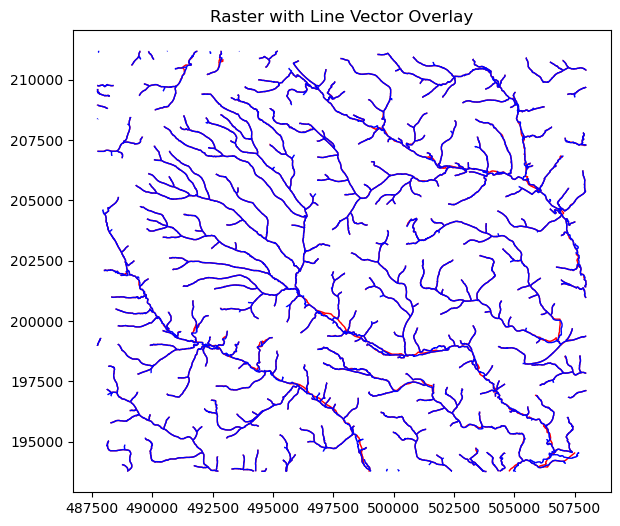

In [29]:
# Open raster
with rasterio.open(extracted_dem) as src:
    raster = src.read(1)  # Read the first band
    minx, maxx, miny, maxy = src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top
    extent = [minx, maxx, miny, maxy]

# Open stream networks
gen_rivers = gpd.read_file("streamlines.shp")
burned_rivers = gpd.read_file(burned_streamlines)
#os_rivers = gpd.read_file("WatercourseLink.shp")
#os_rivers = os_rivers.clip((minx, miny, maxx, maxy))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
#show(raster, extent=extent, ax=ax, cmap="terrain")  # Adjust cmap as needed
burned_rivers.plot(ax=ax, edgecolor="red", linewidth=1)
gen_rivers.plot(ax=ax, edgecolor="blue", linewidth=1)  # Overlay line vector


plt.title("Raster with Line Vector Overlay")
plt.show()